In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mlxtend.plotting import plot_pca_correlation_graph

In [2]:
df = pd.read_csv(r"C:\Users\RamziAbdelhafidh\Documents\Openclassrooms\Projet 3\data\final_df.csv")

In [3]:
df.dtypes

nutriscore_score           float64
nutriscore_grade            object
pnns_groups_1               object
pnns_groups_2               object
energy_100g                float64
fat_100g                   float64
saturated-fat_100g         float64
carbohydrates_100g         float64
sugars_100g                float64
proteins_100g              float64
salt_100g                  float64
sodium_100g                float64
nutrition-score-fr_100g    float64
dtype: object

# Analyse univariée

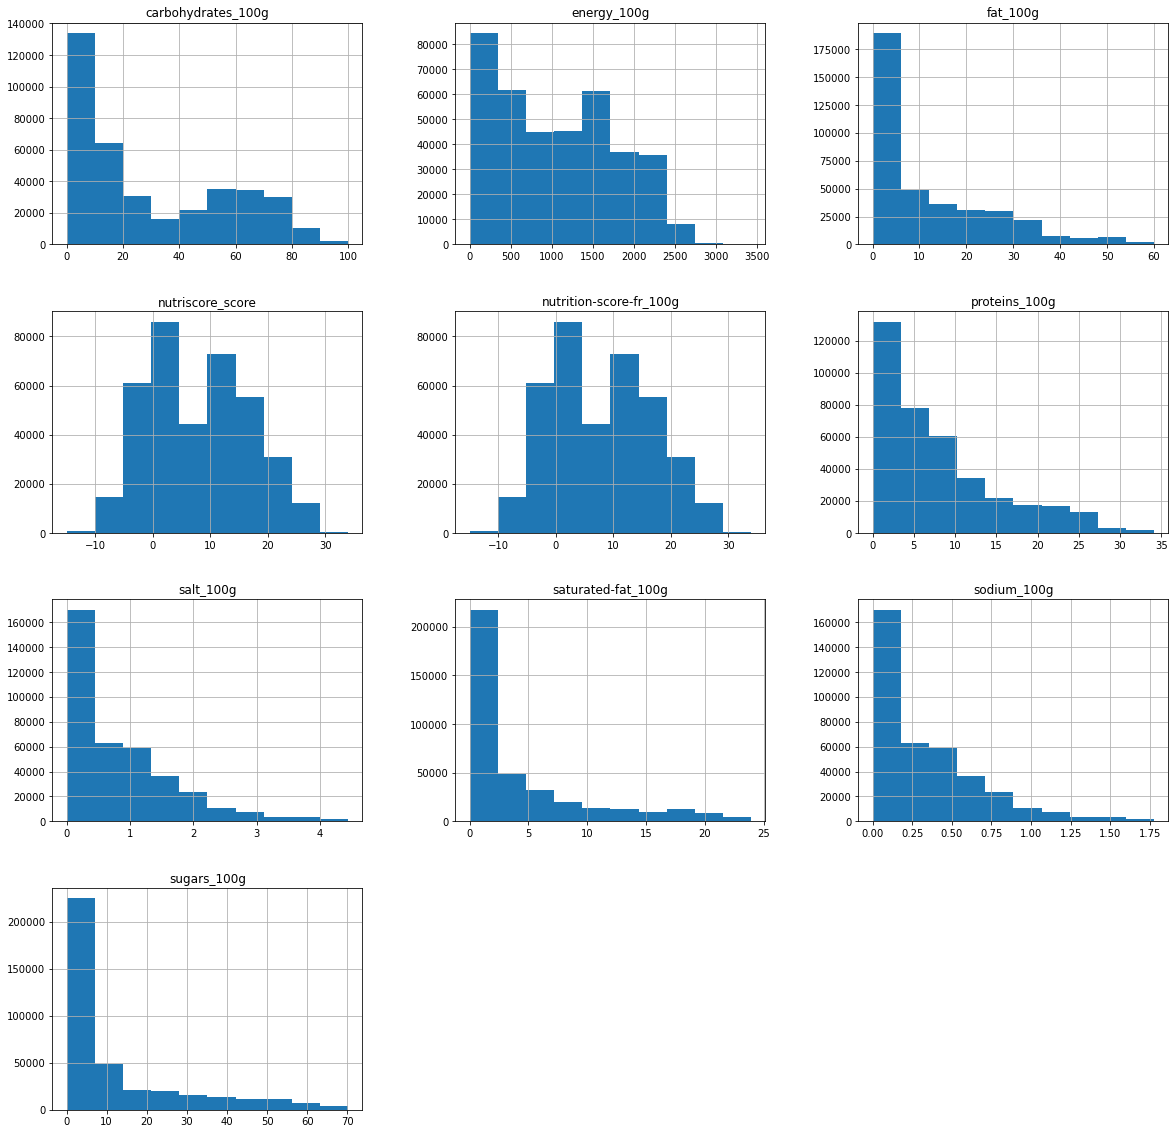

In [4]:
df.select_dtypes(include=float).hist(figsize=(20, 20))
plt.show()

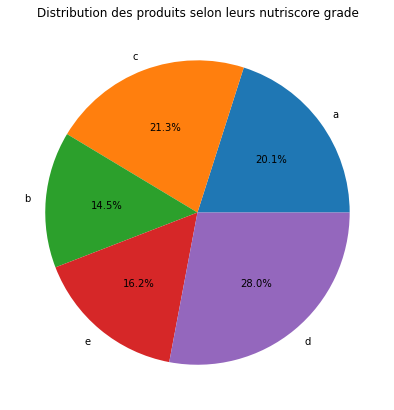

In [5]:
# Définir une liste qui va contenir le nombre d'occurrence de chaque nutriscore grade dans la colonne nutriscore_grade
counts = [list(df['nutriscore_grade']).count(nut_grade) for nut_grade in df['nutriscore_grade'].unique()]
percentages = [counts[i]/np.array(counts).sum() for i in range(len(counts))]
# Tracer l'histogramme de répartition des produits selon leurs nutriscore grade
plt.figure(figsize=(7, 7))
plt.pie(x=percentages, labels=list(df['nutriscore_grade'].unique()), autopct='%1.1f%%',)
plt.title('Distribution des produits selon leurs nutriscore grade')
plt.show()

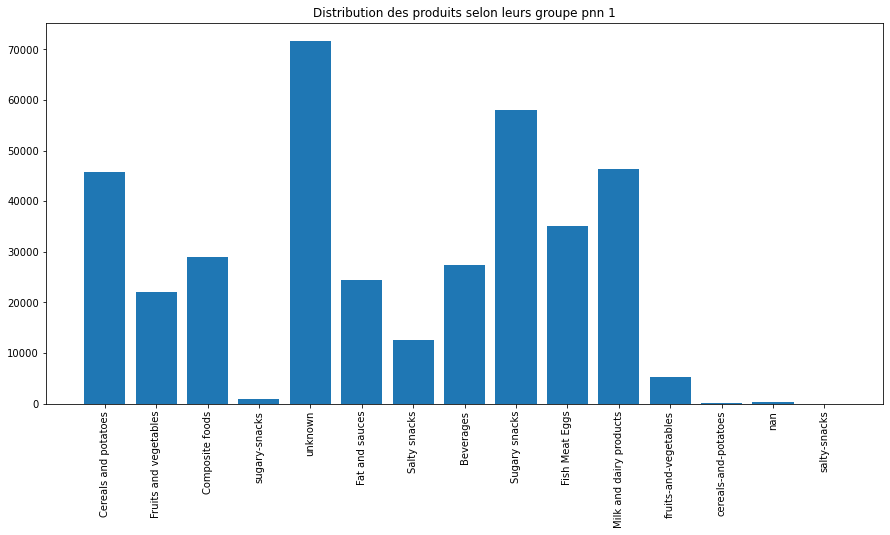

In [6]:
# Définir une liste qui va contenir le nombre d'occurrence de chaque groupe PNN 1
counts = [list(df['pnns_groups_1']).count(nut_grade) for nut_grade in df['pnns_groups_1'].unique()]
# Tracer l'histogramme de répartition des produits selon leurs groupe_pnn_1
groups = [str(group) for group in df['pnns_groups_1'].unique()]
plt.figure(figsize=(15, 7))
plt.xticks(range(len(groups)), groups, rotation=90)
plt.bar(groups, counts)
plt.title('Distribution des produits selon leurs groupe pnn 1')
plt.show()

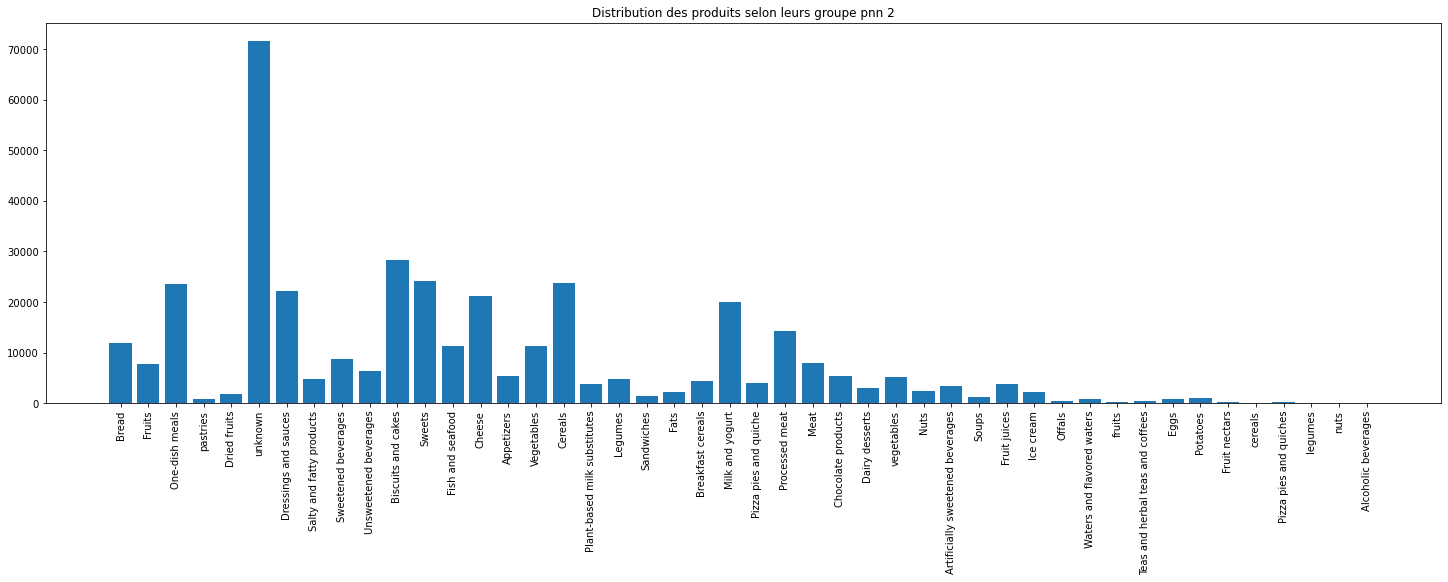

In [7]:
# Définir une liste qui va contenir le nombre d'occurrence de chaque groupe PNN 2
counts = [list(df['pnns_groups_2']).count(nut_grade) for nut_grade in df['pnns_groups_2'].unique()]
# Tracer l'histogramme de répartition des produits selon leurs groupe_pnn_2
groups = [str(group) for group in df['pnns_groups_2'].unique()]
plt.figure(figsize=(25, 7))
plt.xticks(range(len(groups)), groups, rotation=90)
plt.bar(groups, counts)
plt.title('Distribution des produits selon leurs groupe pnn 2')
plt.show()

# Analyse multivariée

## entre variables continues

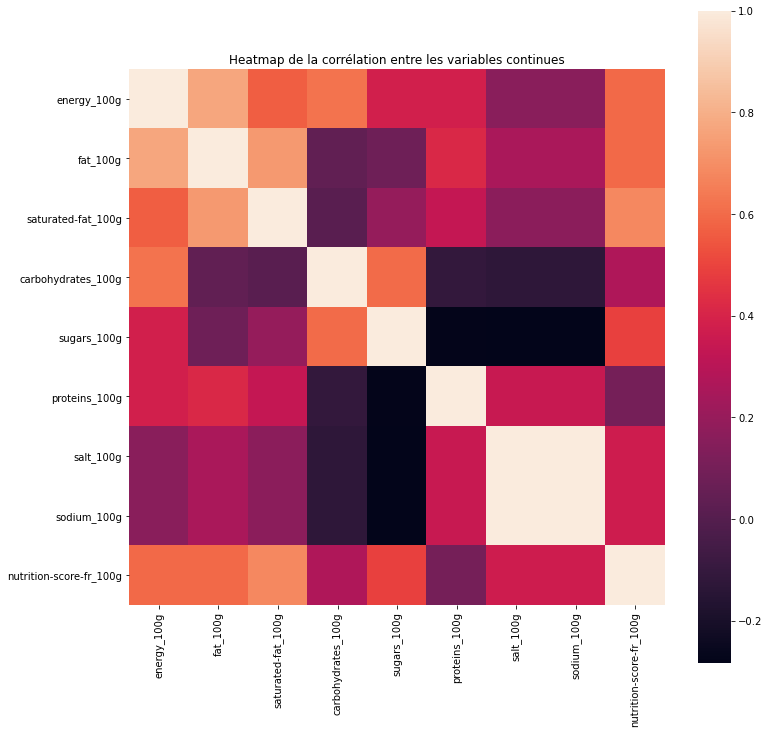

In [11]:
corr = df.select_dtypes(include=float).iloc[:, 1:].corr()
plt.figure(figsize=(12, 12))
plt.title('Heatmap de la corrélation entre les variables continues')
sns.heatmap(corr, vmax=1, square=True)

In [12]:
# Tests statistiques de corrélation
# Les deux variables qui ont une distribution normale sont nutriscore_score et nutrition-score-fr_100g
data1 = df['nutriscore_score']
data2 = df['nutrition-score-fr_100g']
stat, p = pearsonr(data1, data2)
print('stat=%.2f, p=%.3f' % (stat, p))

threshold = 0.05
if p > threshold:
    print('Probably independent')
else:
    print('Probably dependent')

stat=1.00, p=0.000
Probably dependent


## entre variables continues et variables catégorielles

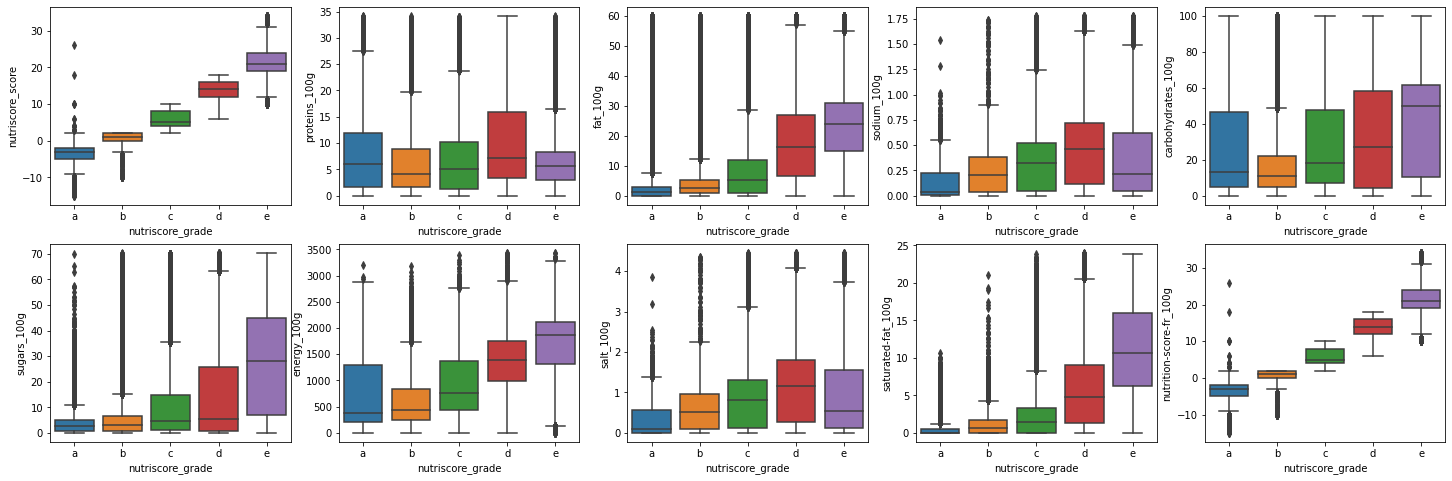

In [13]:
fig, ax = plt.subplots(2, 5, figsize = (25, 8))
i=0
j=0
for column in list(df.select_dtypes(include=float).columns):
    sns.boxplot(x = 'nutriscore_grade', y = column, data=df, order=['a', 'b', 'c', 'd', 'e'], ax = ax[i%2, j%5])
    i+=1
    j+=1

In [14]:
# Test ANOVA (test de la moyenne)
data_a = df.loc[df.nutriscore_grade=='a']['proteins_100g']
data_b = df.loc[df.nutriscore_grade=='b']['proteins_100g']
data_c = df.loc[df.nutriscore_grade=='c']['proteins_100g']
data_d = df.loc[df.nutriscore_grade=='d']['proteins_100g']
data_e = df.loc[df.nutriscore_grade=='e']['proteins_100g']
stat, p = f_oneway(data_a, data_b, data_c, data_d, data_e)
print('stat=%.3f, p=%f' % (stat, p))
if p > 0.05:
    print('Probably the same distribution')
else:
    print('Probably different distributions')
    
# --> les deux variables sont dépendantes

stat=3286.901, p=0.000000
Probably different distributions


In [15]:
# Test ANOVA (test de la moyenne)
data_a = df.loc[df.nutriscore_grade=='a']['sodium_100g']
data_b = df.loc[df.nutriscore_grade=='b']['sodium_100g']
data_c = df.loc[df.nutriscore_grade=='c']['sodium_100g']
data_d = df.loc[df.nutriscore_grade=='d']['sodium_100g']
data_e = df.loc[df.nutriscore_grade=='e']['sodium_100g']
stat, p = f_oneway(data_a, data_b, data_c, data_d, data_e)
print('stat=%.3f, p=%f' % (stat, p))
if p > 0.05:
    print('Probably the same distribution')
else:
    print('Probably different distributions')

stat=16378.429, p=0.000000
Probably different distributions


In [16]:
# Test ANOVA (test de la moyenne)
data_a = df.loc[df.nutriscore_grade=='a']['salt_100g']
data_b = df.loc[df.nutriscore_grade=='b']['salt_100g']
data_c = df.loc[df.nutriscore_grade=='c']['salt_100g']
data_d = df.loc[df.nutriscore_grade=='d']['salt_100g']
data_e = df.loc[df.nutriscore_grade=='e']['salt_100g']
stat, p = f_oneway(data_a, data_b, data_c, data_d, data_e)
print('stat=%.3f, p=%f' % (stat, p))
if p > 0.05:
    print('Probably the same distribution')
else:
    print('Probably different distributions')

stat=16378.941, p=0.000000
Probably different distributions


In [17]:
# Kruskal-Wallis H Test (test de la distribution)
from scipy.stats import kruskal
data_a = df.loc[df.nutriscore_grade=='a']['salt_100g']
data_b = df.loc[df.nutriscore_grade=='b']['salt_100g']
data_c = df.loc[df.nutriscore_grade=='c']['salt_100g']
data_d = df.loc[df.nutriscore_grade=='d']['salt_100g']
data_e = df.loc[df.nutriscore_grade=='e']['salt_100g']
stat, p = kruskal(data_a, data_b, data_c, data_d, data_e)
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Probably the same distribution')
else:
    print('Probably different distributions')

stat=57353.588, p=0.000
Probably different distributions


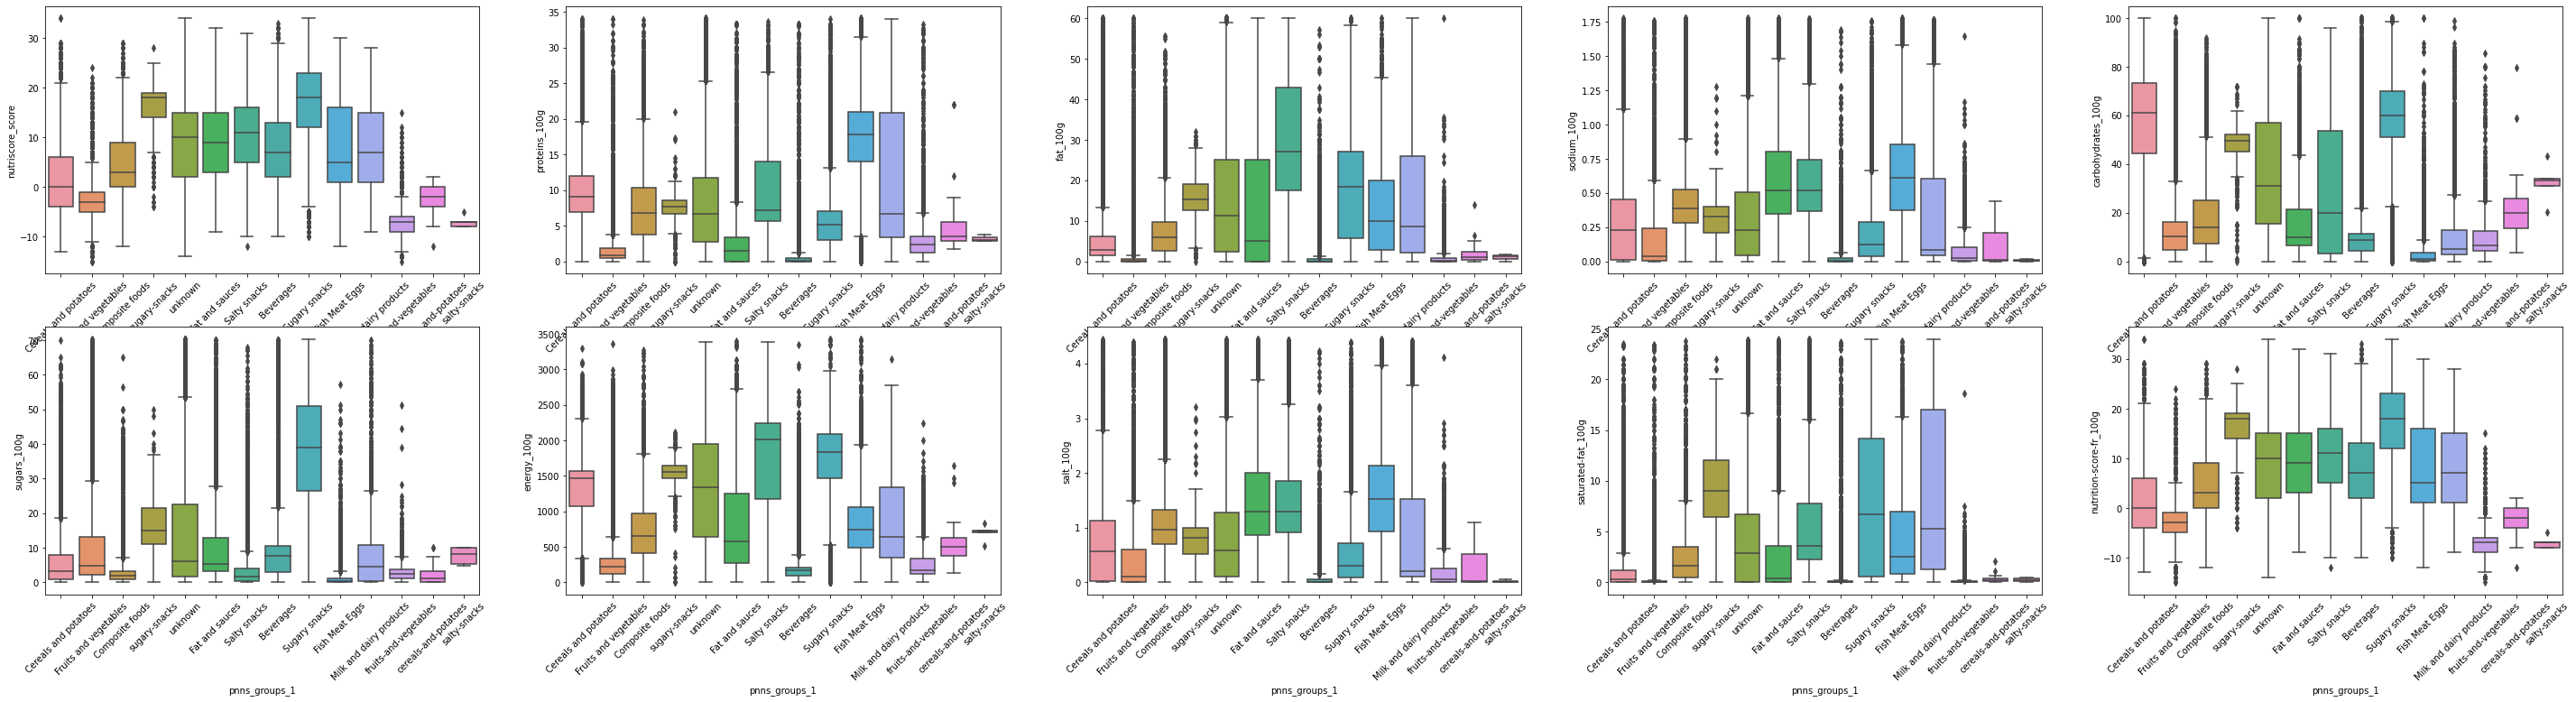

In [18]:
fig, ax = plt.subplots(2, 5, figsize = (50, 12))
i=0
j=0
for column in list(df.select_dtypes(include=float).columns):
    sns.boxplot(x = 'pnns_groups_1', y = column, data=df, ax = ax[i%2, j%5])
    ax[i%2, j%5].set_xticklabels(ax[i%2, j%5].get_xticklabels(),rotation=45)
    i+=1
    j+=1

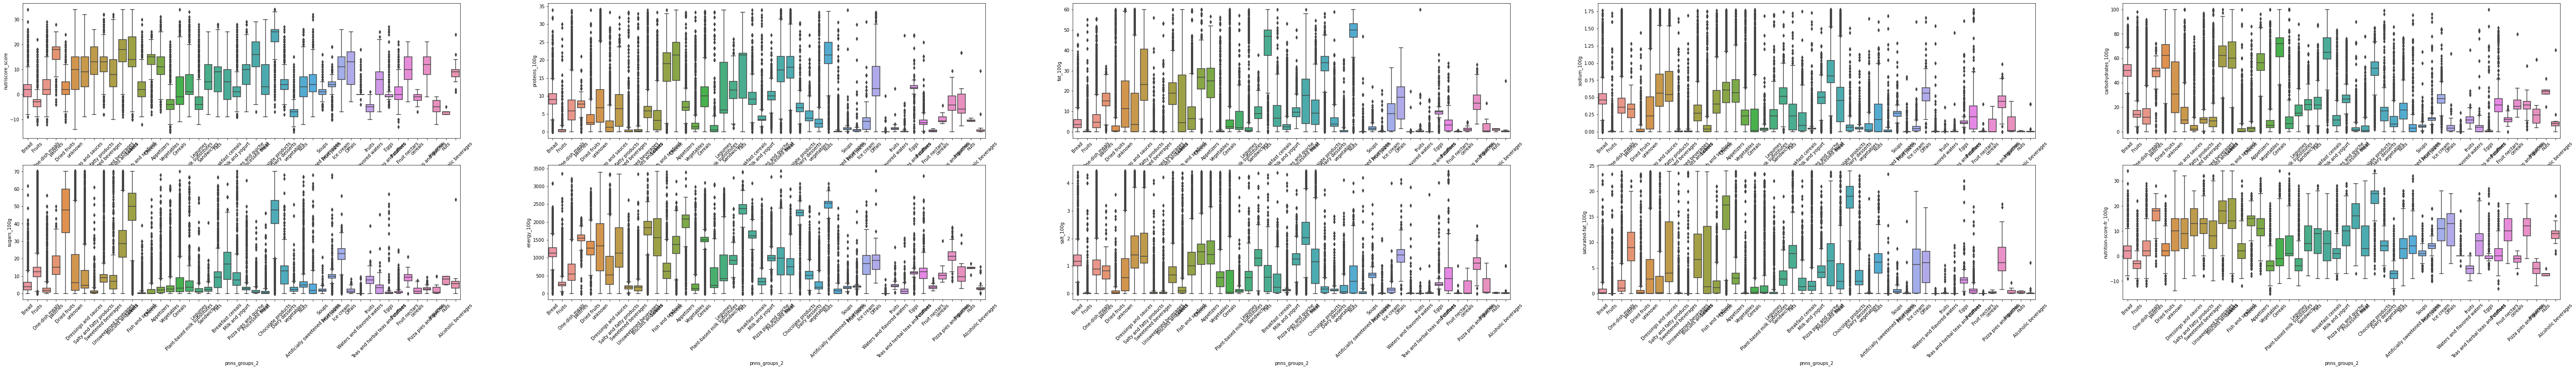

In [19]:
fig, ax = plt.subplots(2, 5, figsize = (100, 12))
i=0
j=0
for column in list(df.select_dtypes(include=float).columns):
    sns.boxplot(x = 'pnns_groups_2', y = column, data=df, ax = ax[i%2, j%5])
    ax[i%2, j%5].set_xticklabels(ax[i%2, j%5].get_xticklabels(),rotation=45)
    i+=1
    j+=1

## entre variables catégorielles

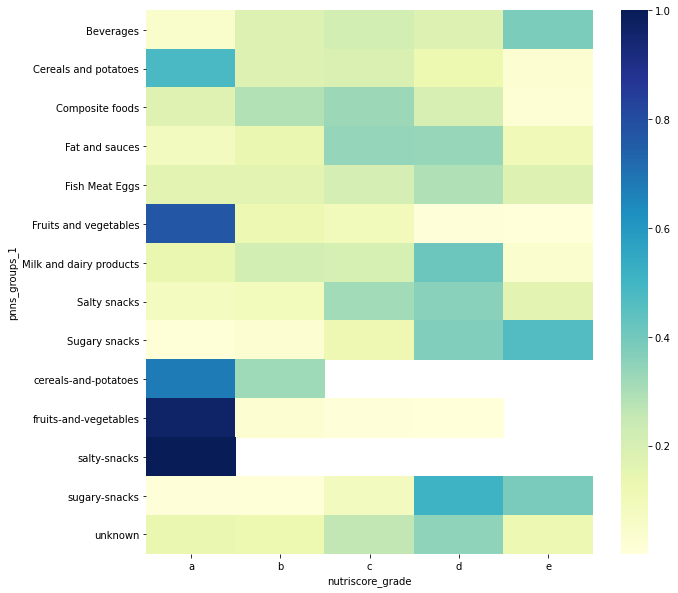

In [20]:
table = df[['pnns_groups_1', 'nutriscore_grade']].pivot_table(index='pnns_groups_1', \
                                                              columns='nutriscore_grade', \
                                                              aggfunc=len, \
                                                              margins=True, \
                                                              margins_name='Total')
table_normalised = table.loc[:,"a":"e"].div(table['Total'], axis=0)

fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(table_normalised.drop('Total', axis=0), cmap="YlGnBu", ax=ax)

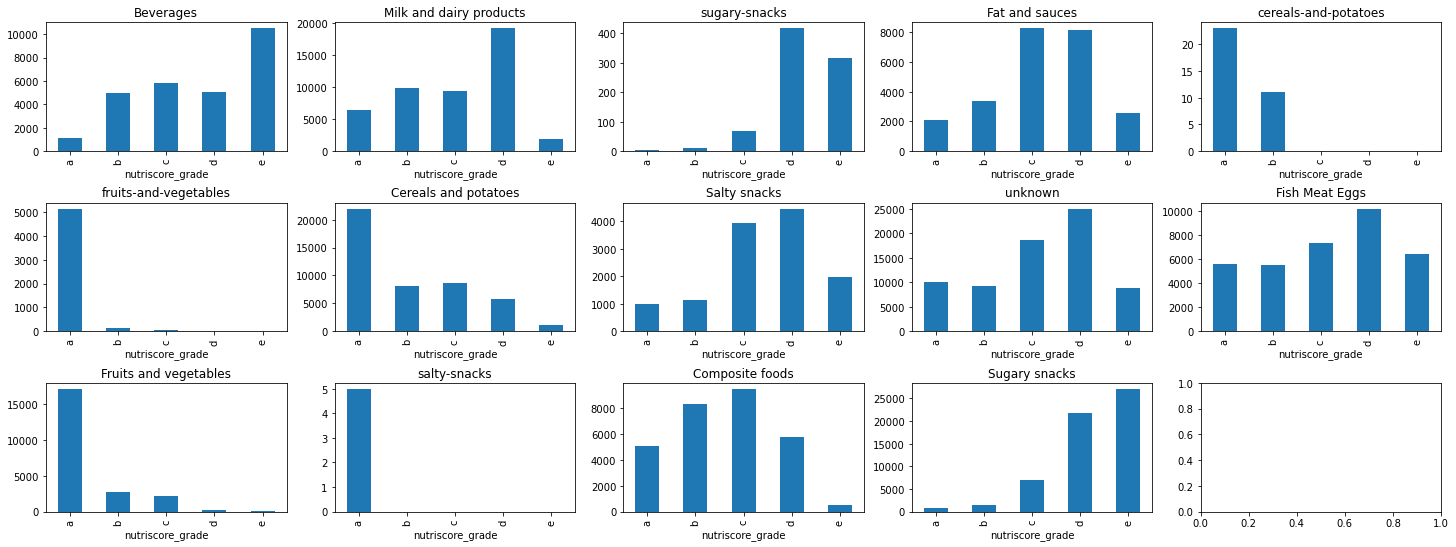

In [21]:
table = df[['pnns_groups_1', 'nutriscore_grade']].pivot_table(index='pnns_groups_1', \
                                                              columns='nutriscore_grade', \
                                                              aggfunc=len, \
                                                              margins=False)
indexes = table.index.values.tolist()

fig, ax = plt.subplots(3, 5, figsize=(25, 9))
plt.subplots_adjust(hspace=0.4)
for i in range(len(indexes)):
    pnn_group_name = indexes[i]
    table.loc[pnn_group_name].plot.bar(title=pnn_group_name, ax=ax[i%3, i%5])
    

In [22]:
table

nutriscore_grade,a,b,c,d,e
pnns_groups_1,,,,,
Beverages,1095.0,4967.0,5836.0,5020.0,10489.0
Cereals and potatoes,21971.0,8132.0,8622.0,5790.0,1167.0
Composite foods,5050.0,8301.0,9456.0,5710.0,522.0
Fat and sauces,2069.0,3342.0,8258.0,8182.0,2537.0
Fish Meat Eggs,5581.0,5497.0,7375.0,10195.0,6387.0
Fruits and vegetables,17079.0,2761.0,2110.0,171.0,24.0
Milk and dairy products,6323.0,9849.0,9305.0,19101.0,1834.0
Salty snacks,978.0,1146.0,3935.0,4458.0,1980.0
Sugary snacks,711.0,1465.0,7004.0,21692.0,27085.0


In [23]:
stat, p, dof, expected = chi2_contingency(np.array(table.fillna(0), dtype=int).tolist())
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Probably independent')
else:
    print('Probably dependent')

stat=191596.751, p=0.000
Probably dependent


# PCA : Principal Component Analysis

In [24]:
# selection des features en éliminant les colonnes nutriscore_score et nutrition-score-fr_100g
features = list(df.select_dtypes(include=float).columns)
features.remove('nutriscore_score')
features.remove('nutrition-score-fr_100g')
# extraction des features
x = df.loc[:, features].values
# extraction de la target
y = df.loc[:,['nutriscore_grade']].values
# Standardization des features (comme PCA est sensible à l'échelle)
x = StandardScaler().fit_transform(x)

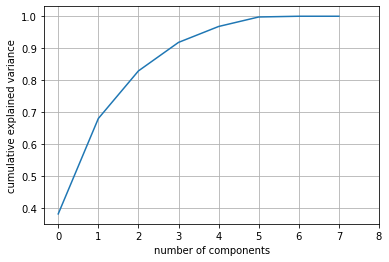

In [25]:
# visualisation de la densité cumulative de la variance expliquée en fonction du nombre des composantes
pca = PCA().fit(x)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.xticks(range(9))
plt.grid()

In [26]:
# fitter le PCA avec un nombre de composantes égal à 3
pca = PCA(n_components=3)
principalComponents = pca.fit_transform(x)
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['principal component 1', 'principal component 2', 'principal component 3'])
finalDf = pd.concat([principalDf, df[['nutriscore_grade']]], axis = 1)

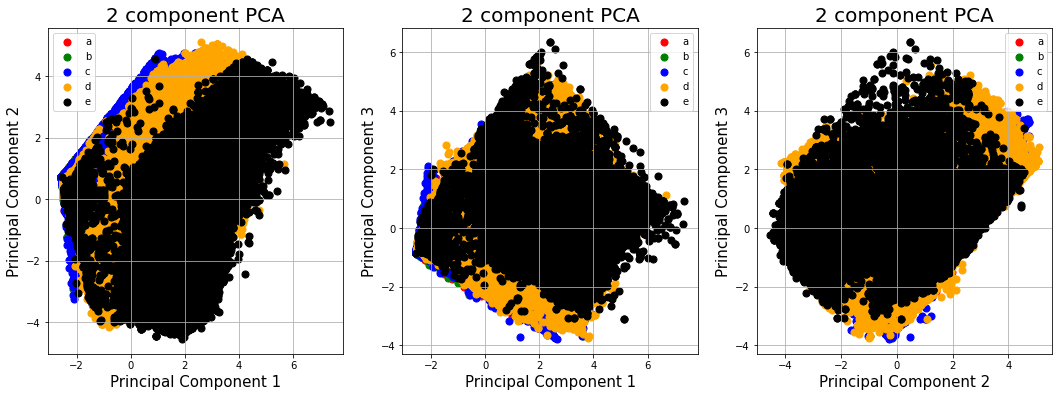

In [27]:
fig, ax = plt.subplots(1, 3, figsize = (18,6))
 
ax[0].set_xlabel('Principal Component 1', fontsize = 15)
ax[0].set_ylabel('Principal Component 2', fontsize = 15)
ax[0].set_title('2 component PCA', fontsize = 20)

ax[1].set_xlabel('Principal Component 1', fontsize = 15)
ax[1].set_ylabel('Principal Component 3', fontsize = 15)
ax[1].set_title('2 component PCA', fontsize = 20)

ax[2].set_xlabel('Principal Component 2', fontsize = 15)
ax[2].set_ylabel('Principal Component 3', fontsize = 15)
ax[2].set_title('2 component PCA', fontsize = 20)

targets = ['a', 'b', 'c', 'd', 'e']
colors = ['red', 'green', 'blue', 'orange', 'black']

for target, color in zip(targets,colors):
    indicesToKeep = finalDf['nutriscore_grade'] == target
    ax[0].scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
    ax[1].scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 3']
               , c = color
               , s = 50)
    ax[2].scatter(finalDf.loc[indicesToKeep, 'principal component 2']
               , finalDf.loc[indicesToKeep, 'principal component 3']
               , c = color
               , s = 50)

ax[0].legend(targets)
ax[0].grid()

ax[1].legend(targets)
ax[1].grid()

ax[2].legend(targets)
ax[2].grid()

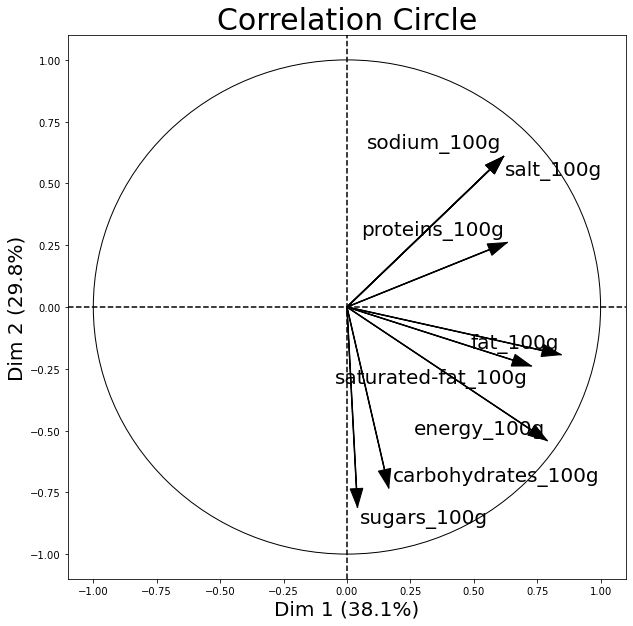

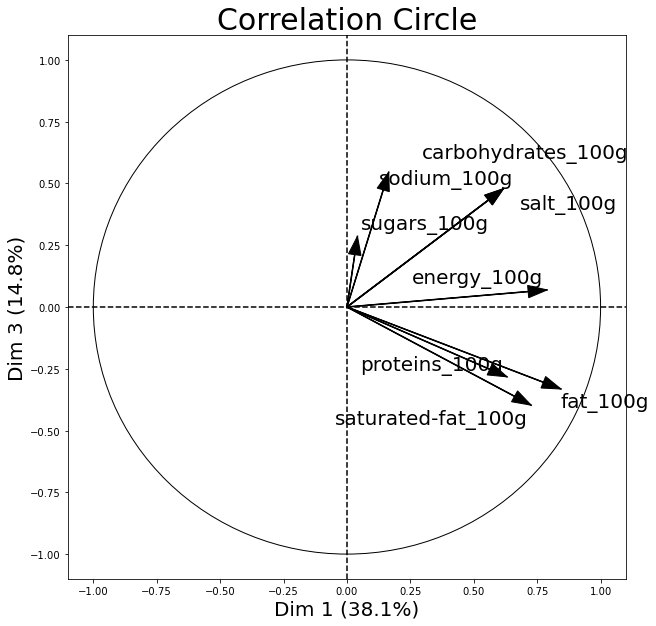

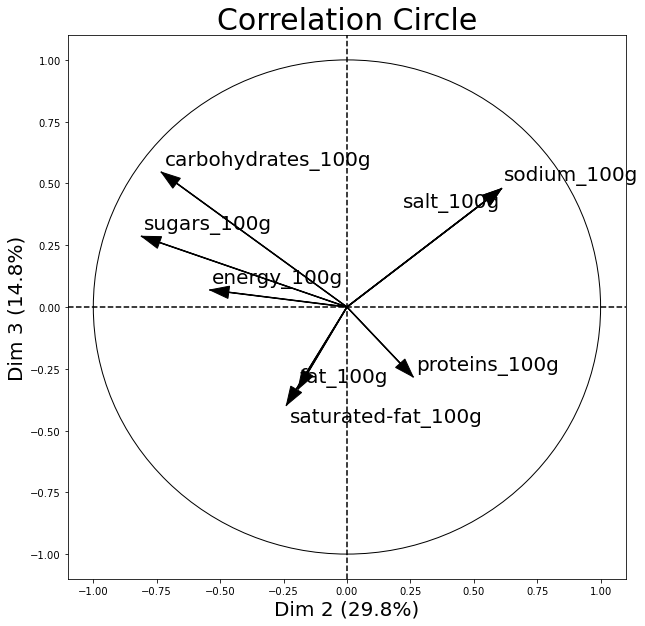

In [28]:
components_indexes = [[0, 1], [0, 1, 2], [0, 1, 2]]
dimensions = [[1, 2], [1, 3], [2, 3]]
for i in range(len(components_indexes)):
    fig, correlation_matrix = plot_pca_correlation_graph(x,
                                                        features,
                                                        X_pca=principalComponents[:, components_indexes[i]],
                                                        explained_variance=pca.explained_variance_[components_indexes[i]],
                                                        dimensions=dimensions[i],
                                                        figure_axis_size=10)